## Figure7: Regime diagrams for the particle-laden lock-release experiments

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from functions import apply_filters

# Use given style and colours
from colors import mixing_c_map

plt.style.use("james2026lock.mplstyle")

# load experiment table
metadata = pd.read_csv("data/metadata.csv")
folder = "/Users/cara/Library/CloudStorage/OneDrive-UBC/PhD/Experiments/2025/Experiment_files/datafiles"

# filter for only particle-laden experiments
part_exp_filt = {"type": "part"}
part_exp = apply_filters(metadata, part_exp_filt).reset_index(drop=True)

# constants
rho_part = 2600
d_part = 22e-6
rho_water = 998.2
visc = 1e-3
h0 = 0.25
h = 0.4 * h0
l0 = 0.27

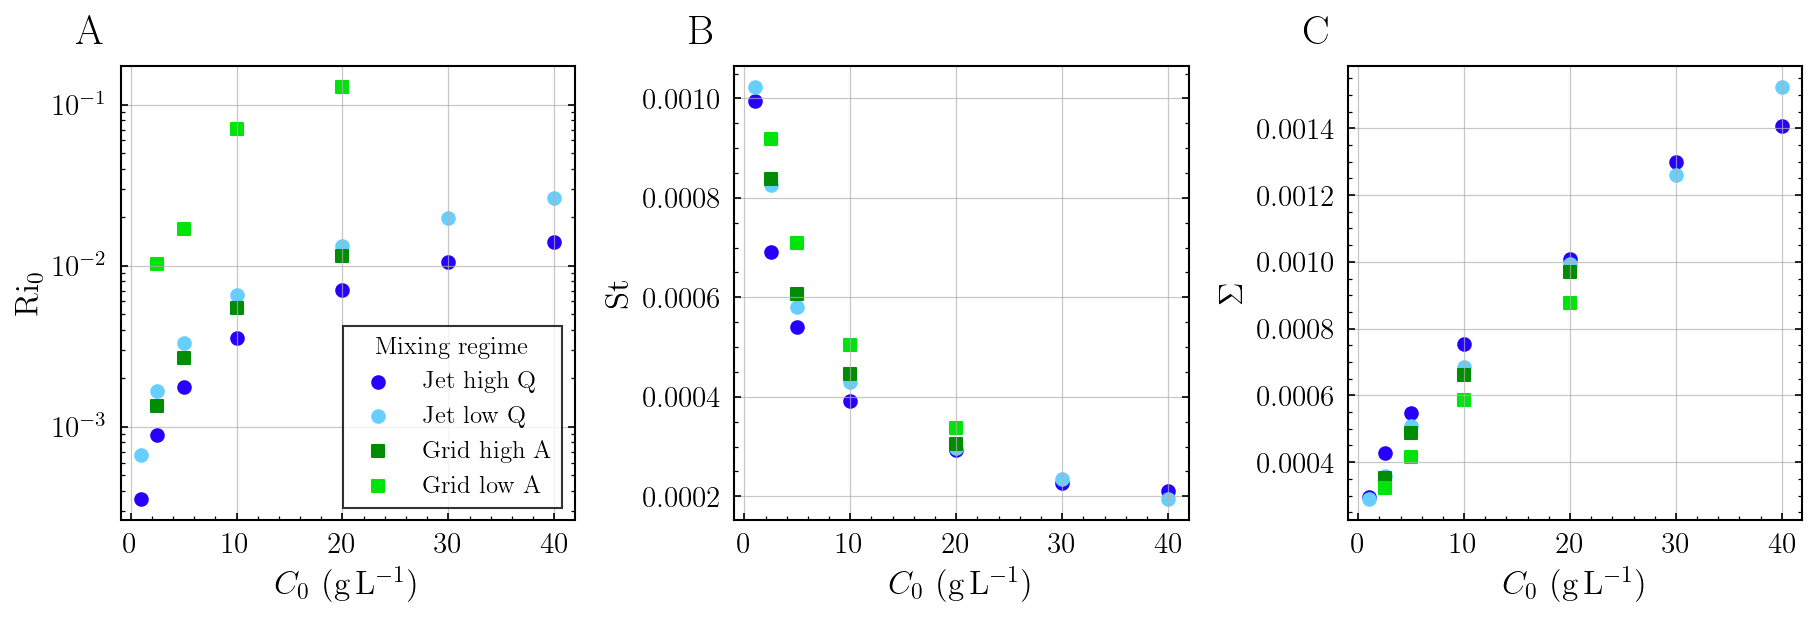

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

# Particle relaxation time (constant across all experiments)
tau_p = rho_part * d_part**2 / (18 * visc)

seen = set()  # to track seen mixing types for legend
label_map = {
    "stagnation high Q": "Jet high Q",
    "stagnation low Q": "Jet low Q",
    "grid high A": "Grid high A",
    "grid low A": "Grid low A",
}

for i, row in part_exp.iterrows():

    # Marker colour from mixing type, shape from whether hose (Q>0) or grid
    c = mixing_c_map.get(row["mixing"])
    m = "o" if row.Q > 0 else "s"

    # Add label only for the first occurrence of each mixing type
    label = label_map.get(row["mixing"]) if row["mixing"] not in seen else None
    seen.add(row["mixing"])

    # --- Panel 1: Richardson number ---
    # Reduced gravity from density difference between current and ambient
    g_prime = 9.81 * row.del_rho / 998.2

    # Ri: ratio of buoyancy to inertial forces
    ri = (g_prime * h0) / (row["U_mix"] ** 2)

    ax[0].scatter(row.C0, ri, marker=m, c=c, label=label)

    # --- Panel 2: Stokes number ---
    # tau_f: convective timescale of the current
    tau_f = row.u_c / l0

    # St: ratio of particle inertia to flow timescale; St << 1 means particles follow the flow
    st = tau_p / tau_f

    ax[1].scatter(row.C0, st, marker=m, c=c, label=label)

    # --- Panel 3: Sedimentation number ---
    # tau_s: time for a particle to settle through the current depth
    tau_s = 18 * visc * h / ((rho_part - rho_water) * 9.81 * d_part**2)

    # Sigma: ratio of convective to settling timescale; Sigma >> 1 means settling dominates
    sed = tau_f / tau_s

    ax[2].scatter(row.C0, sed, marker=m, c=c, label=label)

# --- Axes formatting ---
ax[0].set_yscale("log")  # log scale to capture wide range of Ri
ax[0].set_xlabel(r"$C_0$ (g\,L$^{-1}$)")
ax[0].set_ylabel(r"Ri$_0$")

ax[1].set_xlabel(r"$C_0$ (g\,L$^{-1}$)")
ax[1].set_ylabel(r"St")

ax[2].set_xlabel(r"$C_0$ (g\,L$^{-1}$)")
ax[2].set_ylabel(r"$\Sigma$")

# --- Legend and labels ---
ax[0].legend(title="Mixing regime", loc="lower right")
for axis, label in zip(ax, ["A", "B", "C"]):
    axis.annotate(
        label,
        xy=(-0.1, 1.05),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )

# --- Save and show ---
fig.get_layout_engine().set(wspace=0.05)
plt.savefig("figures/figure_7.png", dpi=300, bbox_inches="tight")
plt.show()